<a href="https://colab.research.google.com/github/wismajylksn/Customer-Churn-Prediction/blob/main/%5BPortofolio_1%5D_Customer_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Portfolio Project: Telco Customer Churn Prediction
**Dikerjakan oleh:** Wisma Jaya Laksana

**Latar Belakang Bisnis:**
Perusahaan telekomunikasi memiliki masalah tingginya angka pelanggan yang berhenti berlangganan (Churn). Biaya untuk mencari pelanggan baru jauh lebih mahal daripada mempertahankan pelanggan lama.

**Tujuan Project:**
Membangun model Machine Learning untuk mendeteksi pelanggan mana yang berpotensi untuk *churn*, sehingga tim Marketing dapat memberikan promo retensi tepat sasaran sebelum pelanggan tersebut benar-benar pergi.

In [ ]:
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')

df_churn = pd.read_csv('/content/drive/MyDrive/Portofolio_ML_Wisma/WA_Fn-UseC_-Telco-Customer-Churn.csv')

display(df_churn.head())

print("\n--- Info Struktur Data ---")
df_churn.info()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



--- Info Struktur Data ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilli

In [ ]:
# 1. Paksa ubah kolom TotalCharges jadi angka (numeric)
df_churn['TotalCharges'] = pd.to_numeric(df_churn['TotalCharges'], errors='coerce')

# 2. cek lagi, data yang bolong ada berapa
print("Jumlah data kosong setelah dibedah:")
print(df_churn.isnull().sum())

Jumlah data kosong setelah dibedah:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


## 🛠️ Fase 1: Data Cleaning & Preprocessing
Data mentah seringkali memiliki kecacatan (seperti sel yang kosong atau tipe data yang salah). Pada tahap ini, saya mengubah tipe data tagihan menjadi format angka dan membuang 11 baris data yang kosong agar tidak mengganggu proses pembelajaran mesin (AI).

## 📈 Fase 2: Exploratory Data Analysis (EDA)
Sebelum melatih model, penting untuk memahami pola data secara visual. Di bawah ini adalah visualisasi untuk membandingkan lama berlangganan (tenure) antara pelanggan yang setia dan pelanggan yang kabur.

/tmp/ipykernel_648/3285884397.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df_churn, palette='Set2')


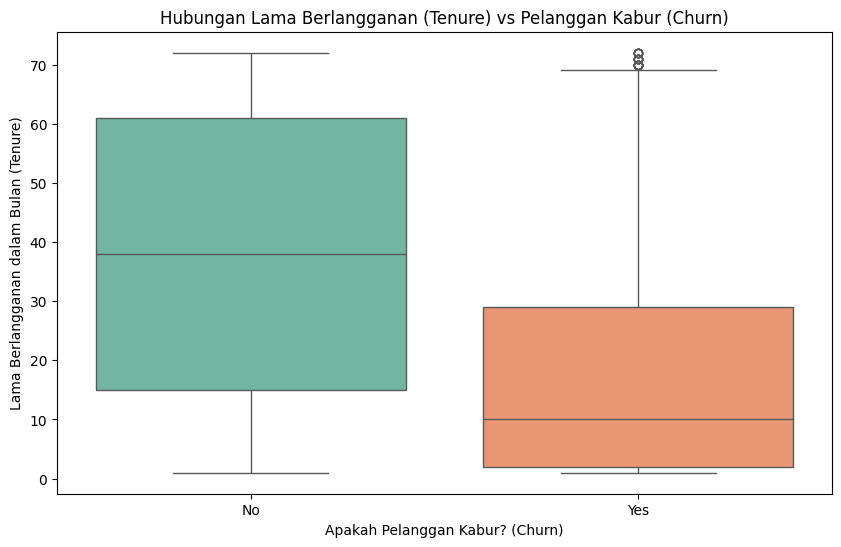

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. buang dulu 11 baris data yang kosong tadi (Sisa Fase 3)
df_churn = df_churn.dropna()

# 2. MULAI FASE 2: BIKIN GRAFIK! 🎨
plt.figure(figsize=(10, 6))

# Kita bikin grafik kotak (Boxplot) untuk melihat sebaran data
# Sumbu X = Churn (Kabur atau Tidak)
# Sumbu Y = tenure (Berapa bulan dia sudah langganan)
sns.boxplot(x='Churn', y='tenure', data=df_churn, palette='Set2')

plt.title('Hubungan Lama Berlangganan (Tenure) vs Pelanggan Kabur (Churn)')
plt.xlabel('Apakah Pelanggan Kabur? (Churn)')
plt.ylabel('Lama Berlangganan dalam Bulan (Tenure)')

plt.show()

In [ ]:
# Menghitung jumlah pelanggan yang Setia (No) dan Kabur (Yes)
jumlah_churn = df_churn['Churn'].value_counts()

print("--- Laporan Jumlah Pelanggan ---")
print(jumlah_churn)

# Menghitung persentasenya
persentase_churn = df_churn['Churn'].value_counts(normalize=True) * 100
print("\n--- Persentase (%) ---")
print(persentase_churn)

--- Laporan Jumlah Pelanggan ---
Churn
No     5163
Yes    1869
Name: count, dtype: int64

--- Persentase (%) ---
Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


## 🤖 Fase 3: Machine Learning Modeling
Saya menggunakan algoritma **Random Forest Classifier**. Algoritma ini dipilih karena kemampuannya yang sangat baik dalam menangani klasifikasi data pelanggan. Data dibagi menjadi 80% untuk pelatihan dan 20% untuk pengujian.

In [ ]:
# 1. Panggil Scikit-Learn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

print("1. Mempersiapkan Data...")
# Buang kolom customerID
df_bersih = df_churn.drop('customerID', axis=1)

# MAGIC WAND: Ubah SEMUA teks, jadi angka 1 dan 0
df_ml = pd.get_dummies(df_bersih, drop_first=True)

# 2. Tentukan Soal (X) dan Kunci Jawaban (y)
# Catatan: Setelah di-get_dummies, kolom 'Churn' berubah nama jadi 'Churn_Yes'
X = df_ml.drop('Churn_Yes', axis=1) # X = Semua kolom KECUALI Churn_Yes
y = df_ml['Churn_Yes']              # y = Target yang mau ditebak (1=Kabur, 0=Setia)

# 3. Potong Data (80% Buku Latihan, 20% Lembar Ujian)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("2. 🕵️‍♂️ Detektif AI sedang belajar dari masa lalu...")
# 4. Panggil AI Random Forest dan suruh belajar!
detektif_churn = RandomForestClassifier(random_state=42)
detektif_churn.fit(X_train, y_train)
print("3. ✅ Detektif AI selesai belajar!")

# 5. Uji AI
y_pred = detektif_churn.predict(X_test)

# 6. Cetak Akurasi
akurasi = accuracy_score(y_test, y_pred)
print("\n--- 🎓 RAPOR DETEKTIF CHURN WISMA 🎓 ---")
print(f"Skor Akurasi Tebakan AI: {akurasi * 100:.2f}%")

1. Mempersiapkan Data...
2. 🕵️‍♂️ Detektif AI sedang belajar dari masa lalu...
3. ✅ Detektif AI selesai belajar!

--- 🎓 RAPOR DETEKTIF CHURN WISMA 🎓 ---
Skor Akurasi Tebakan AI: 78.54%


### 🔍 Evaluasi Model: Confusion Matrix (Versi Awal)
Untuk melihat detail performa AI, saya menggunakan *Confusion Matrix*. Akurasi 78% di atas ternyata masih memiliki kelemahan kritis:
* AI berhasil mendeteksi **178** pelanggan yang mau kabur (True Positive).
* Namun, AI "kebobolan" dan gagal mendeteksi **196** pelanggan yang akhirnya benar-benar kabur (False Negative).
Di dunia bisnis, *False Negative* ini sangat berbahaya karena perusahaan murni kehilangan pelanggan tanpa sempat memberikan penawaran retensi.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128373 (\N{SLEUTH OR SPY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


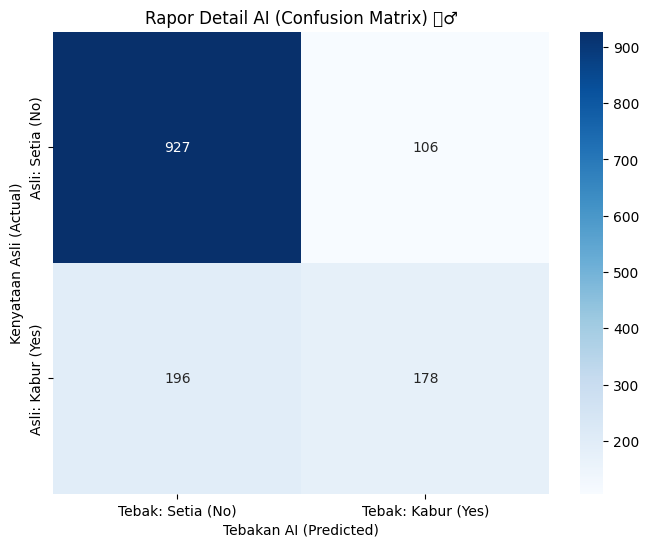

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Bandingin Kunci Jawaban vs Tebakan AI
cm = confusion_matrix(y_test, y_pred)

# 2. Gambar biar cakep pakai Seaborn (Warna Biru)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tebak: Setia (No)', 'Tebak: Kabur (Yes)'],
            yticklabels=['Asli: Setia (No)', 'Asli: Kabur (Yes)'])

plt.title('Rapor Detail AI (Confusion Matrix) 🕵️‍♂️')
plt.xlabel('Tebakan AI (Predicted)')
plt.ylabel('Kenyataan Asli (Actual)')
plt.show()

### 📖 Panduan Membaca 4 Kotak Confusion Matrix:
Matriks di atas membagi tebakan AI menjadi 4 skenario bisnis nyata:

* **Kotak Kiri Atas (Setia & Ditebak Setia):** Pelanggan yang memang setia dan AI benar memprediksinya. Perusahaan aman dan tidak perlu melakukan apa-apa.
* **Kotak Kanan Bawah (Kabur & Ditebak Kabur):** Pelanggan yang berniat berhenti dan AI berhasil mendeteksinya. Ini adalah **Target Utama** tim marketing untuk diberikan penawaran retensi (diskon/promo).
* **Kotak Kanan Atas (Setia, TAPI Ditebak Kabur - Salah Alarm):** AI curiga pelanggan ini mau kabur, padahal aslinya mereka setia. Dampaknya: Perusahaan mungkin membuang sedikit biaya untuk memberikan promo yang sebenarnya tidak diperlukan.
* **Kotak Kiri Bawah (Kabur, TAPI Ditebak Setia - Kebobolan):** AI gagal mendeteksi pelanggan yang benar-benar kabur. Dampaknya: Ini adalah kerugian paling fatal karena perusahaan kehilangan pelanggan tanpa perlawanan sama sekali. Fokus optimasi model adalah mengecilkan angka di kotak ini.


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


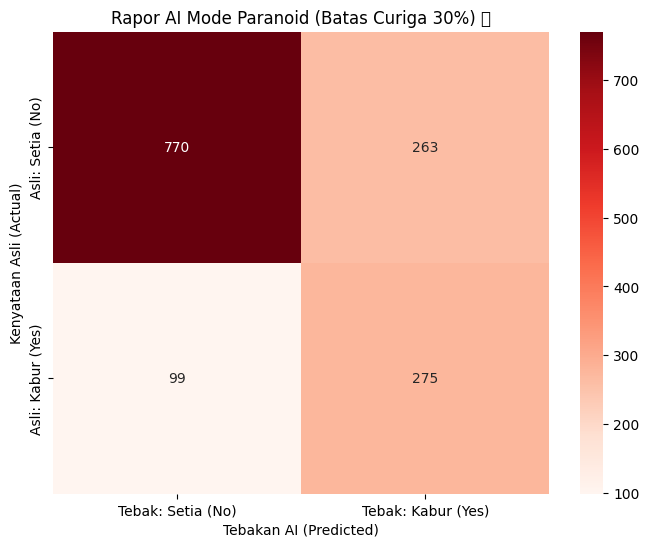


Skor Akurasi Keseluruhan: 74.27%


In [ ]:
# 1. Kita minta AI Versi 1 ngeluarin ANGKA PERSENTASE keyakinannya (bukan cuma Yes/No)
# predict_proba ini ngeluarin angka keyakinan dari 0.0 sampai 1.0
persentase_yakin = detektif_churn.predict_proba(X_test)[:, 1]

# 2. KITA AKTIFKAN MODE PARANOID! (Ubah batas dari 50% jadi 30%)
batas_kecurigaan = 0.30
y_pred_paranoid = (persentase_yakin >= batas_kecurigaan).astype(int)

# 3. cetak Matriks Kebingungan Versi Paranoid
cm_paranoid = confusion_matrix(y_test, y_pred_paranoid)

plt.figure(figsize=(8, 6))
# Dikasih warna merah untuk mode paranoid
sns.heatmap(cm_paranoid, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Tebak: Setia (No)', 'Tebak: Kabur (Yes)'],
            yticklabels=['Asli: Setia (No)', 'Asli: Kabur (Yes)'])

plt.title('Rapor AI Mode Paranoid (Batas Curiga 30%) 🚨')
plt.xlabel('Tebakan AI (Predicted)')
plt.ylabel('Kenyataan Asli (Actual)')
plt.show()

# 4. Cek akurasi barunya
akurasi_paranoid = accuracy_score(y_test, y_pred_paranoid)
print(f"\nSkor Akurasi Keseluruhan: {akurasi_paranoid * 100:.2f}%")

### 🚨 Optimasi Model: Threshold Tuning (Mode Sensitivitas Tinggi)
Untuk menekan angka kebobolan (196 pelanggan), saya melakukan eksperimen dengan menurunkan *threshold* (batas deteksi) model dari 50% menjadi 30%. Model dipaksa untuk lebih waspada terhadap ciri-ciri pelanggan yang ingin *churn*.

**Hasil Perbandingan Bisnis:**
* **Kebobolan (False Negative) turun drastis:** Dari 196 pelanggan menjadi hanya **99 pelanggan**.
* **Trade-off:** Angka "Salah Alarm" (False Positive) memang naik menjadi 263, di mana perusahaan mungkin akan memberikan promo diskon kepada pelanggan yang sebenarnya setia. Namun, dari segi hitungan bisnis, biaya pemberian promo retensi jauh lebih murah dibandingkan kerugian kehilangan 99 pelanggan.

## 💡 Kesimpulan & Rekomendasi Bisnis
Melalui proses *Threshold Tuning* (mengubah batas sensitivitas AI menjadi 30%), model ini dioptimalkan untuk menjadi mode 'High-Recall'.
* **Hasil:** Angka kebobolan (False Negatives) berhasil ditekan dari 196 pelanggan menjadi hanya 99 pelanggan.
* **Rekomendasi:** Tim Marketing disarankan untuk memprioritaskan penawaran diskon loyalitas kepada pelanggan baru (usia langganan 10-30 bulan) yang dideteksi *'Yes'* oleh model ini.